In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import random

# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [2]:
# %% CELDA 2: CARGA Y DIVISIÓN DE DATOS (70% Train, 15% Val, 15% Test)
transform = transforms.Compose([
    transforms.ToTensor()
])

# Descargamos las partes estándar
dataset_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataset_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Las unimos para tener las 60,000 juntas
full_dataset = torch.utils.data.ConcatDataset([dataset_train, dataset_test])

# Calculamos los tamaños exactos
total_size = len(full_dataset)
train_size = int(0.70 * total_size) # 42,000
val_size = int(0.15 * total_size)   # 9,000
test_size = total_size - train_size - val_size # 9,000

# Dividimos aleatoriamente
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], 
    generator=torch.Generator().manual_seed(42) # Semilla para que sea reproducible
)

# Creamos los 3 DataLoaders (con num_workers=0 para que no se trabe)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Datos divididos: Entrenamiento={len(train_dataset)}, Validación={len(val_dataset)}, Prueba={len(test_dataset)}")

Datos divididos: Entrenamiento=42000, Validación=9000, Prueba=9000


In [ ]:
def add_gaussian_noise(imgs, sigma=0.1):
    noise = torch.randn_like(imgs) * sigma
    return torch.clamp(imgs + noise, 0., 1.)

def add_salt_and_pepper_noise(imgs, amount=0.05):
    noisy_imgs = imgs.clone()
    batch_size, channels, h, w = noisy_imgs.size()
    for i in range(batch_size):
        prob = torch.rand(h, w)
        salt = prob < (amount / 2)
        pepper = (prob > (amount / 2)) & (prob < amount)
        for c in range(channels):
            noisy_imgs[i, c, salt] = 1.0
            noisy_imgs[i, c, pepper] = 0.0
    return noisy_imgs

def convert_to_grayscale(imgs):
    return transforms.Grayscale(num_output_channels=1)(imgs)

def apply_inpainting_mask(imgs, mask_size=12):
    masked_imgs = imgs.clone()
    h, w = imgs.shape[2], imgs.shape[3]
    x = random.randint(0, w - mask_size)
    y = random.randint(0, h - mask_size)
    masked_imgs[:, :, y:y+mask_size, x:x+mask_size] = 0.0
    return masked_imgs

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64, in_channels=3): # Añadido in_channels
        super(ConvAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1), # Usar in_channels aquí
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        
        self.fc_encode = nn.Linear(64 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 64 * 4 * 4)
        
        # Decoder (Siempre sale a 3 canales para RGB)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # La salida siempre es 3 para recuperar el color
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), 
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        latent = self.fc_encode(x)
        x = self.fc_decode(latent)
        return self.decoder(x)

In [ ]:
def evaluate_model(model, dataloader, task, param_value):
    """Calcula la pérdida MSE promedio en un dataloader específico."""
    model.eval()
    criterion = nn.MSELoss()
    running_loss = 0.0
    with torch.no_grad():
        for imgs, _ in dataloader:
            targets = imgs.to(device)
            if task == 'gaussian': inputs = add_gaussian_noise(imgs, sigma=param_value)
            elif task == 'sp': inputs = add_salt_and_pepper_noise(imgs, amount=param_value)
            elif task == 'color': inputs = convert_to_grayscale(imgs)
            elif task == 'inpaint': inputs = apply_inpainting_mask(imgs, mask_size=param_value)
            
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
    return running_loss / len(dataloader)

def train_experiment(model, train_loader, val_loader, task, param_value, epochs=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for imgs, _ in train_loader:
            targets = imgs.to(device)
            if task == 'gaussian': inputs = add_gaussian_noise(imgs, sigma=param_value)
            elif task == 'sp': inputs = add_salt_and_pepper_noise(imgs, amount=param_value)
            elif task == 'color': inputs = convert_to_grayscale(imgs)
            elif task == 'inpaint': inputs = apply_inpainting_mask(imgs, mask_size=param_value)
            
            inputs = inputs.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
            
        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        
        # Validación
        epoch_val_loss = evaluate_model(model, val_loader, task, param_value)
        val_losses.append(epoch_val_loss)
        
    return model, train_losses, val_losses # Ahora regresa también el modelo

def visualize_experiment(model, dataloader, task, param_value, title, num_imgs=3):
    model.eval()
    imgs, _ = next(iter(dataloader))
    
    if task == 'gaussian': inputs = add_gaussian_noise(imgs, sigma=param_value)
    elif task == 'sp': inputs = add_salt_and_pepper_noise(imgs, amount=param_value)
    elif task == 'color': inputs = convert_to_grayscale(imgs)
    elif task == 'inpaint': inputs = apply_inpainting_mask(imgs, mask_size=param_value)
        
    with torch.no_grad():
        outputs = model(inputs.to(device)).cpu()
    
    fig, axes = plt.subplots(3, num_imgs, figsize=(9, 6))
    fig.suptitle(title, fontsize=16)
    for i in range(num_imgs):
        axes[0, i].imshow(np.transpose(imgs[i].numpy(), (1, 2, 0)))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original")
        
        axes[1, i].imshow(np.transpose(inputs[i].numpy(), (1, 2, 0)))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Entrada Corrupta")
        
        axes[2, i].imshow(np.transpose(outputs[i].numpy(), (1, 2, 0)))
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("Reconstrucción")
    plt.tight_layout()
    plt.show()

=== INICIANDO BATERÍA DE EXPERIMENTOS ===

>>> Entrenando gaussian sigma=0.1...
Tarea: gaussian (sigma: 0.1)
  - Final Train Loss: 0.007829
  - Final Val Loss:   0.007983
  - Final Test Loss:  0.007920


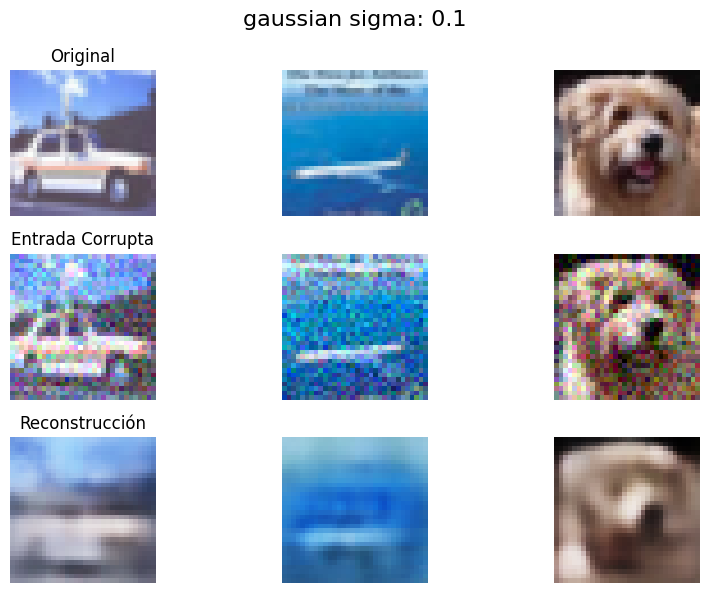


>>> Entrenando gaussian sigma=0.3...
Tarea: gaussian (sigma: 0.3)
  - Final Train Loss: 0.009296
  - Final Val Loss:   0.009442
  - Final Test Loss:  0.009382


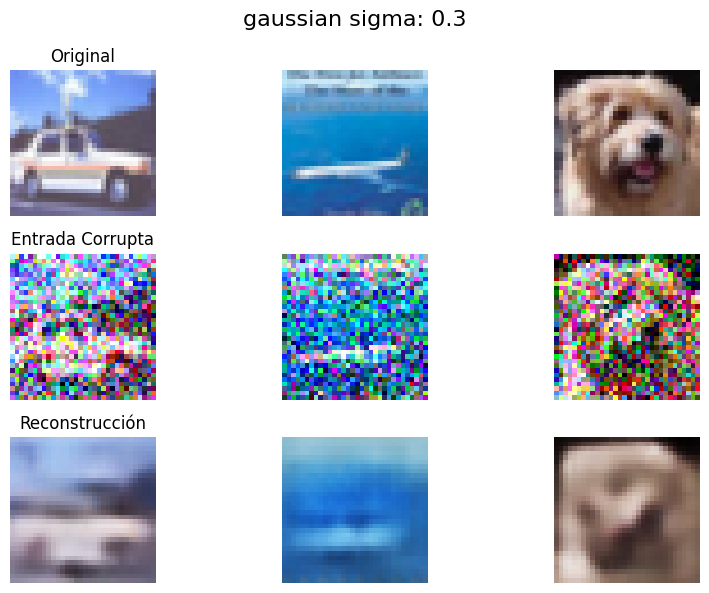


>>> Entrenando gaussian sigma=0.5...
Tarea: gaussian (sigma: 0.5)
  - Final Train Loss: 0.011600
  - Final Val Loss:   0.011695
  - Final Test Loss:  0.011633


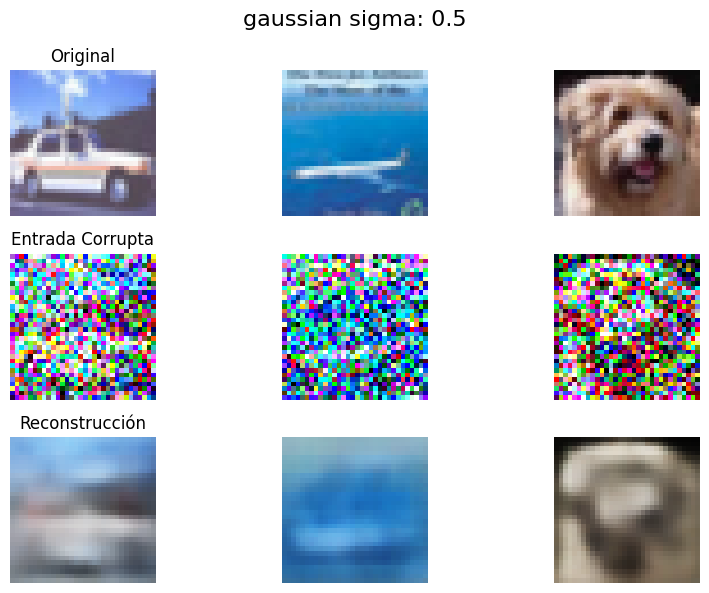


>>> Entrenando sp amount=0.05...
Tarea: sp (amount: 0.05)
  - Final Train Loss: 0.007738
  - Final Val Loss:   0.007930
  - Final Test Loss:  0.007872


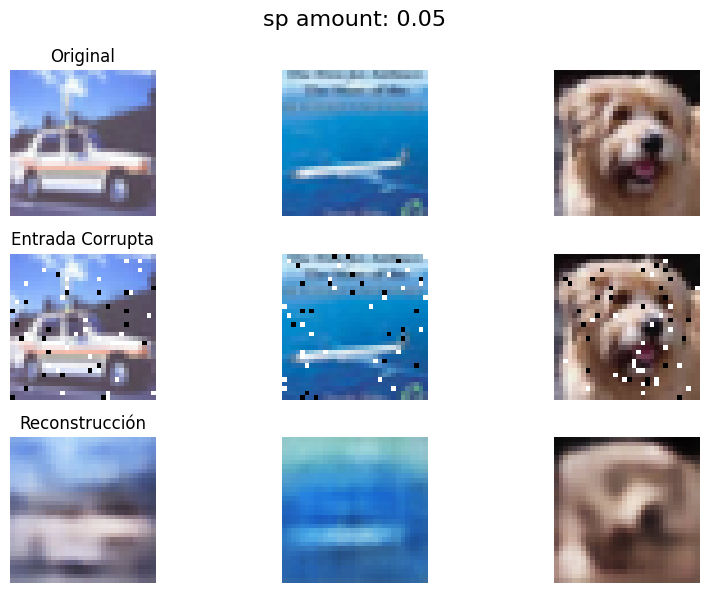


>>> Entrenando sp amount=0.1...
Tarea: sp (amount: 0.1)
  - Final Train Loss: 0.007894
  - Final Val Loss:   0.008047
  - Final Test Loss:  0.007978


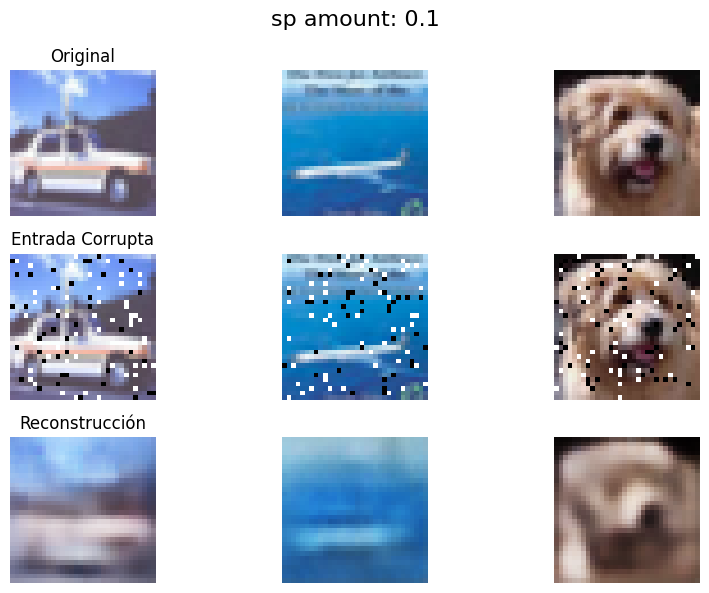


>>> Entrenando sp amount=0.2...
Tarea: sp (amount: 0.2)
  - Final Train Loss: 0.008042
  - Final Val Loss:   0.008233
  - Final Test Loss:  0.008169


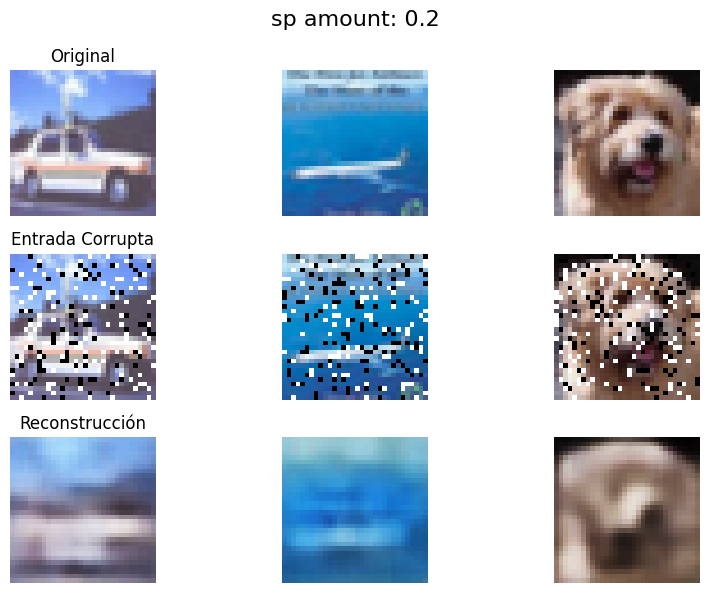


>>> Entrenando color latent_dim=16...
Tarea: color (latent_dim: 16)
  - Final Train Loss: 0.018532
  - Final Val Loss:   0.018970
  - Final Test Loss:  0.019029


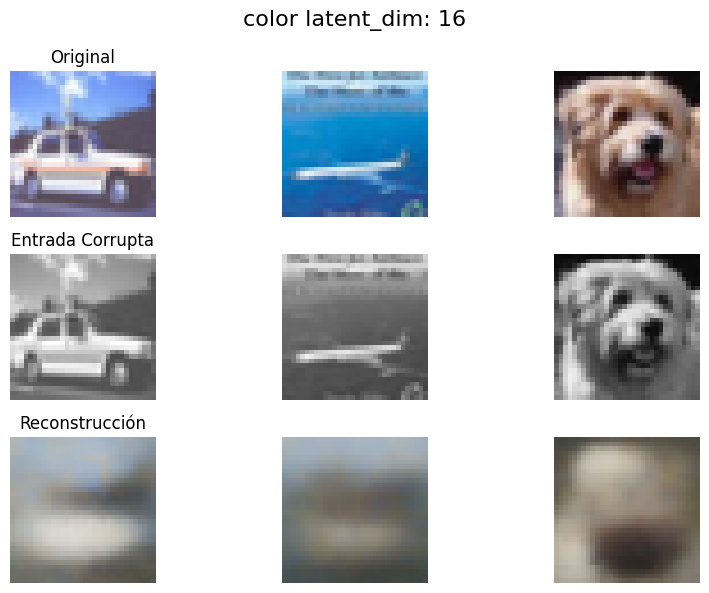


>>> Entrenando color latent_dim=32...
Tarea: color (latent_dim: 32)
  - Final Train Loss: 0.013923
  - Final Val Loss:   0.014857
  - Final Test Loss:  0.014931


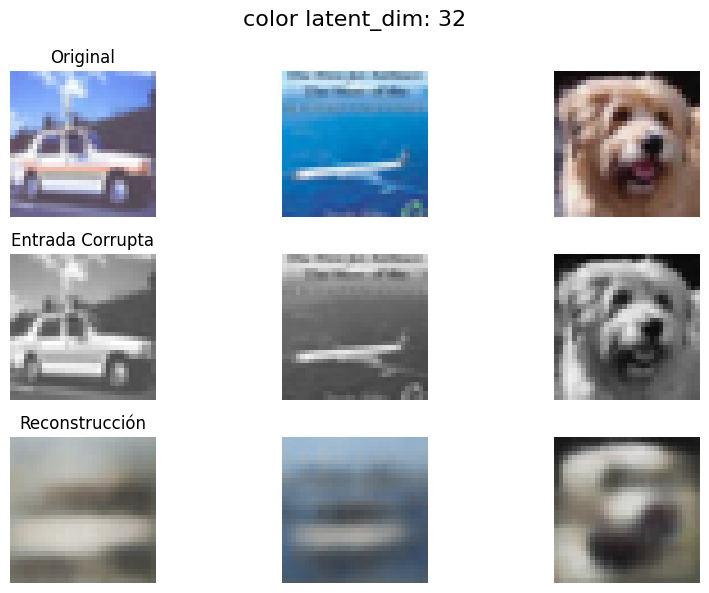


>>> Entrenando color latent_dim=64...
Tarea: color (latent_dim: 64)
  - Final Train Loss: 0.010630
  - Final Val Loss:   0.011730
  - Final Test Loss:  0.011784


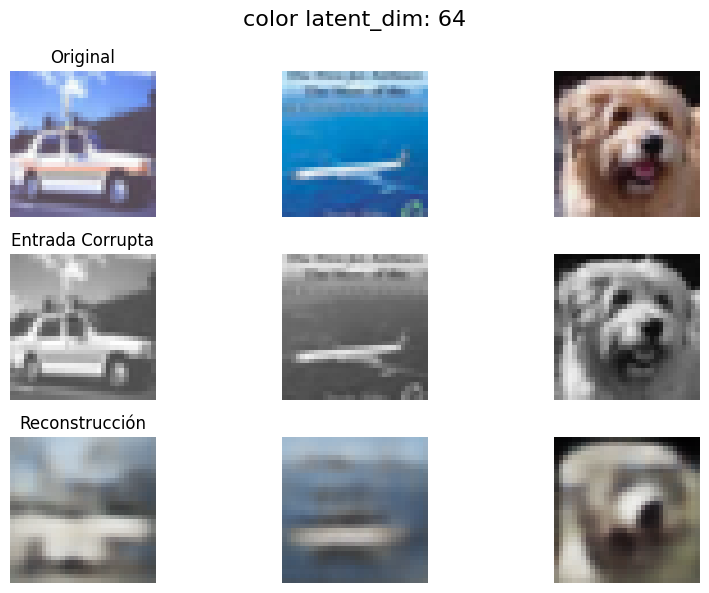


>>> Entrenando inpaint mask_size=8...
Tarea: inpaint (mask_size: 8)
  - Final Train Loss: 0.008295
  - Final Val Loss:   0.008391
  - Final Test Loss:  0.008364


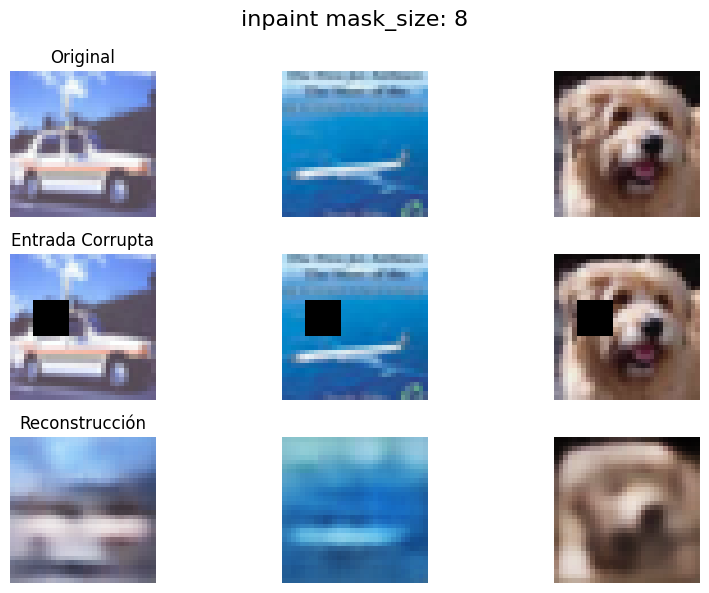


>>> Entrenando inpaint mask_size=12...
Tarea: inpaint (mask_size: 12)
  - Final Train Loss: 0.009761
  - Final Val Loss:   0.009765
  - Final Test Loss:  0.009748


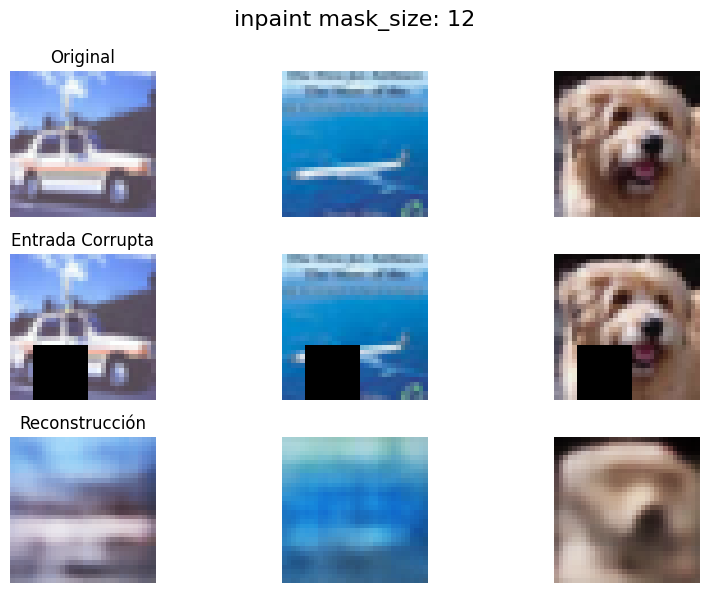


>>> Entrenando inpaint mask_size=16...
Tarea: inpaint (mask_size: 16)
  - Final Train Loss: 0.012117
  - Final Val Loss:   0.012312
  - Final Test Loss:  0.012211


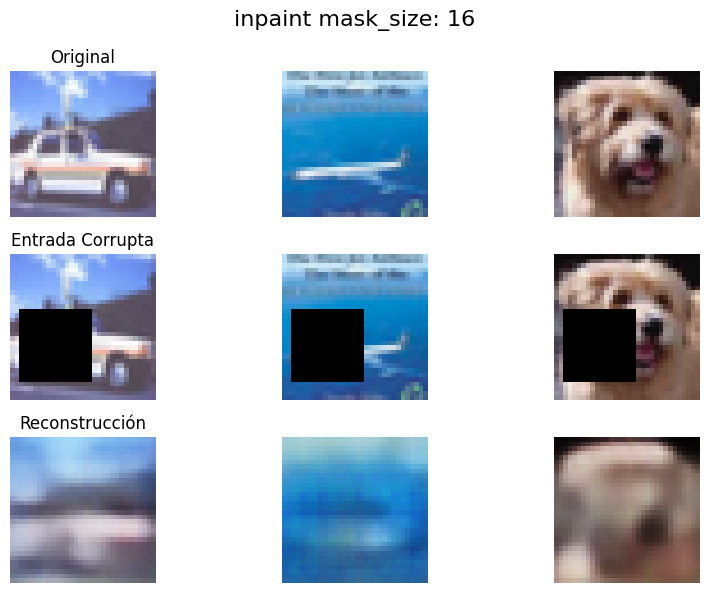


RESUMEN FINAL DE MÉTRICAS (LOSS)
Tarea: gaussian (sigma: 0.1)
  - Final Train Loss: 0.007829
  - Final Val Loss:   0.007983
  - Final Test Loss:  0.007920
--------------------
Tarea: gaussian (sigma: 0.3)
  - Final Train Loss: 0.009296
  - Final Val Loss:   0.009442
  - Final Test Loss:  0.009382
--------------------
Tarea: gaussian (sigma: 0.5)
  - Final Train Loss: 0.011600
  - Final Val Loss:   0.011695
  - Final Test Loss:  0.011633
--------------------
Tarea: sp (amount: 0.05)
  - Final Train Loss: 0.007738
  - Final Val Loss:   0.007930
  - Final Test Loss:  0.007872
--------------------
Tarea: sp (amount: 0.1)
  - Final Train Loss: 0.007894
  - Final Val Loss:   0.008047
  - Final Test Loss:  0.007978
--------------------
Tarea: sp (amount: 0.2)
  - Final Train Loss: 0.008042
  - Final Val Loss:   0.008233
  - Final Test Loss:  0.008169
--------------------
Tarea: color (latent_dim: 16)
  - Final Train Loss: 0.018532
  - Final Val Loss:   0.018970
  - Final Test Loss:  0.019029

In [ ]:
history = {}
EPOCHS = 50 
results_summary = [] # Para guardar los textos y mostrarlos al final

print("=== INICIANDO BATERÍA DE EXPERIMENTOS ===")

def run_and_report(task, params, name_label):
    history[task] = {}
    for p in params:
        print(f"\n>>> Entrenando {task} {name_label}={p}...")
        
        input_ch = 1 if task == 'color' else 3
        l_dim = p if task == 'color' else 64
        
        model = ConvAutoencoder(latent_dim=l_dim, in_channels=input_ch).to(device)
        
        # Entrenar
        model, t_loss, v_loss = train_experiment(model, trainloader, valloader, task, p, EPOCHS)
        
        # Evaluar en Test
        test_loss = evaluate_model(model, testloader, task, p)
        
        # Guardar historial para gráficas
        history[task][p] = {'train': t_loss, 'val': v_loss}
        
        # Guardar y mostrar reporte
        report = (f"Tarea: {task} ({name_label}: {p})\n"
                  f"  - Final Train Loss: {t_loss[-1]:.6f}\n"
                  f"  - Final Val Loss:   {v_loss[-1]:.6f}\n"
                  f"  - Final Test Loss:  {test_loss:.6f}")
        results_summary.append(report)
        print(report)
        
        visualize_experiment(model, testloader, task, p, f'{task} {name_label}: {p}')

# Ejecución de todas las tareas
run_and_report('gaussian', [0.1, 0.3, 0.5], 'sigma')
run_and_report('sp', [0.05, 0.1, 0.2], 'amount')
run_and_report('color', [16, 32, 64], 'latent_dim')
run_and_report('inpaint', [8, 12, 16], 'mask_size')

# --- RESUMEN FINAL ---
print("\n" + "="*40)
print("RESUMEN FINAL DE MÉTRICAS (LOSS)")
print("="*40)
for res in results_summary:
    print(res)
    print("-" * 20)



=== GENERANDO TODAS LAS GRÁFICAS DE CURVAS DE PÉRDIDA ===


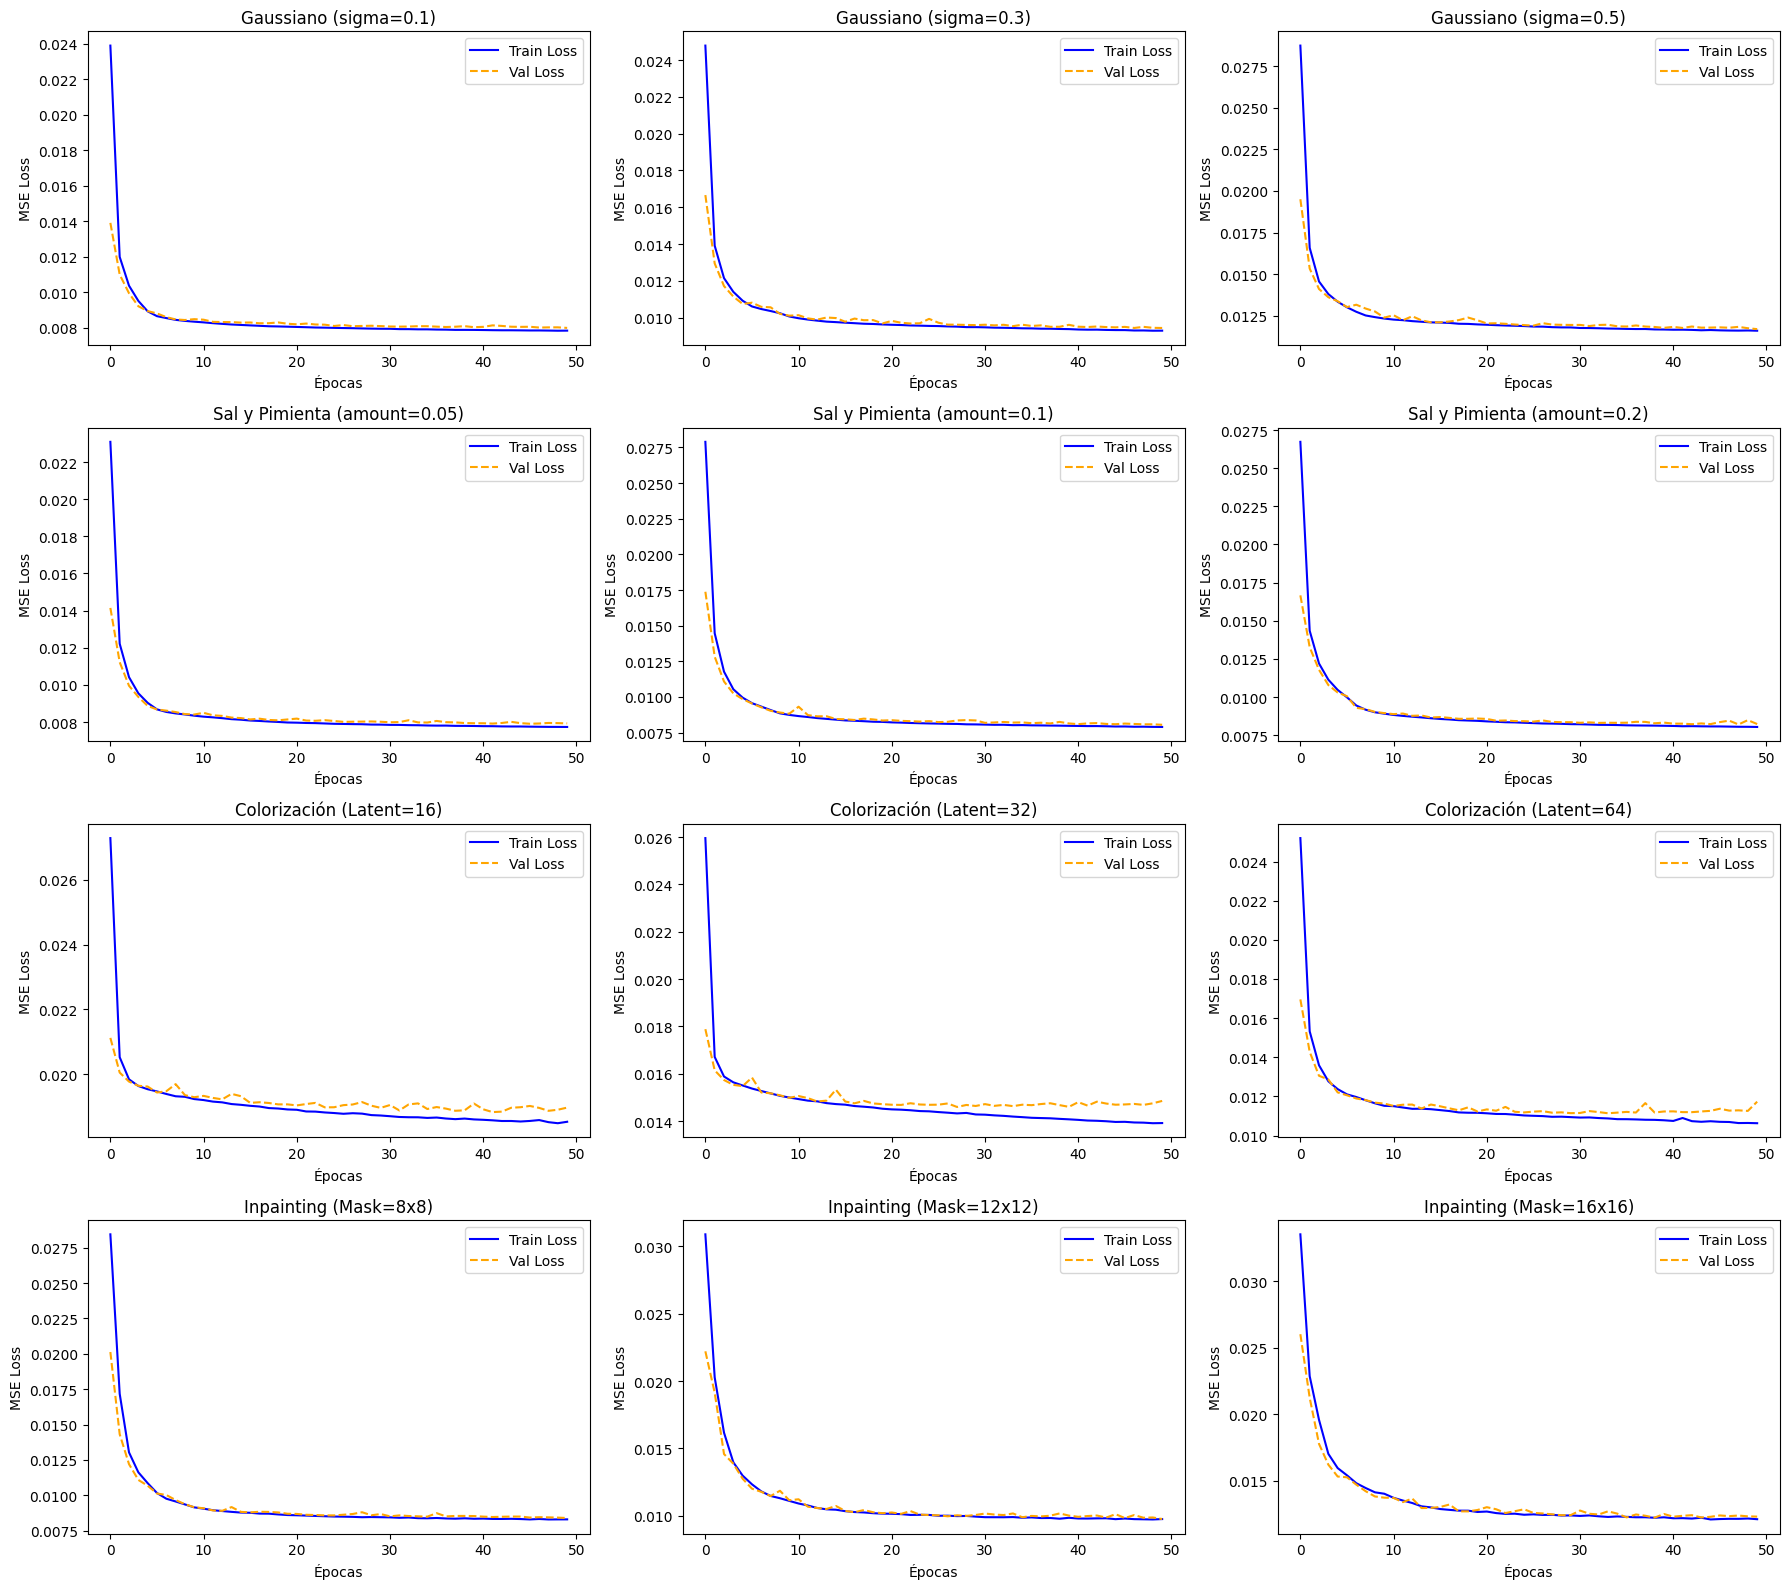

: 

In [ ]:


print("\n=== GENERANDO TODAS LAS GRÁFICAS DE CURVAS DE PÉRDIDA ===")

# Creamos una cuadrícula de 4 filas x 3 columnas
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.subplots_adjust(hspace=0.4) # Un poco de espacio entre las filas

# --- Fila 0: Tarea 1 - Ruido Gaussiano ---
for i, s in enumerate([0.1, 0.3, 0.5]):
    axes[0, i].plot(history['gaussian'][s]['train'], label='Train Loss', color='blue')
    axes[0, i].plot(history['gaussian'][s]['val'], label='Val Loss', color='orange', linestyle='--')
    axes[0, i].set_title(f'Gaussiano (sigma={s})')
    axes[0, i].set_xlabel('Épocas')
    axes[0, i].set_ylabel('MSE Loss')
    axes[0, i].legend()

# --- Fila 1: Tarea 1 - Ruido Sal y Pimienta ---
for i, a in enumerate([0.05, 0.1, 0.2]):
    axes[1, i].plot(history['sp'][a]['train'], label='Train Loss', color='blue')
    axes[1, i].plot(history['sp'][a]['val'], label='Val Loss', color='orange', linestyle='--')
    axes[1, i].set_title(f'Sal y Pimienta (amount={a})')
    axes[1, i].set_xlabel('Épocas')
    axes[1, i].set_ylabel('MSE Loss')
    axes[1, i].legend()

# --- Fila 2: Tarea 2 - Colorización ---
for i, l in enumerate([16, 32, 64]):
    axes[2, i].plot(history['color'][l]['train'], label='Train Loss', color='blue')
    axes[2, i].plot(history['color'][l]['val'], label='Val Loss', color='orange', linestyle='--')
    axes[2, i].set_title(f'Colorización (Latent={l})')
    axes[2, i].set_xlabel('Épocas')
    axes[2, i].set_ylabel('MSE Loss')
    axes[2, i].legend()

# --- Fila 3: Tarea 3 - Inpainting ---
for i, m in enumerate([8, 12, 16]):
    axes[3, i].plot(history['inpaint'][m]['train'], label='Train Loss', color='blue')
    axes[3, i].plot(history['inpaint'][m]['val'], label='Val Loss', color='orange', linestyle='--')
    axes[3, i].set_title(f'Inpainting (Mask={m}x{m})')
    axes[3, i].set_xlabel('Épocas')
    axes[3, i].set_ylabel('MSE Loss')
    axes[3, i].legend()

plt.tight_layout()
plt.show()
plt.show()